In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wine-dataset-for-clustering/wine-clustering.csv


# K-means ML lab 6
Yasir Ahmad
22MIA1064

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

!pip install kneed

In [3]:
data = pd.read_csv("/kaggle/input/wine-dataset-for-clustering/wine-clustering.csv")
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
data.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [5]:
print(data.shape)
print(data.columns)
print(data.dtypes)


(178, 13)
Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object


In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

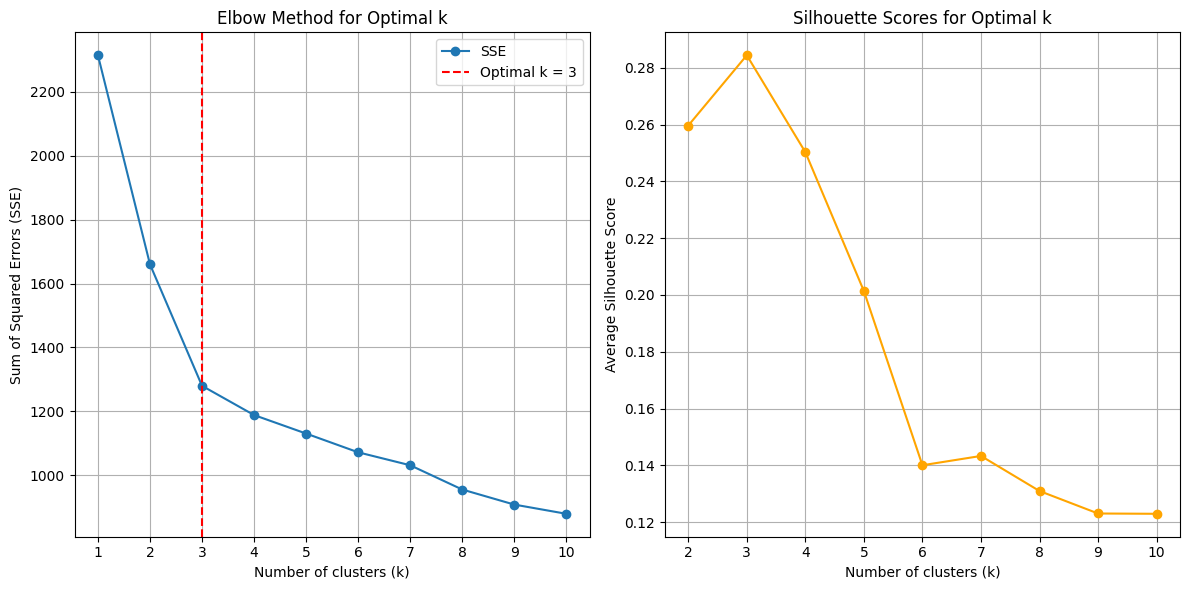

The optimal number of clusters is: 3


In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

def elbow_and_silhouette(df, max_k=10):
    """
    Use the Elbow Method and Silhouette Score to find the optimal number of clusters with KMeans++ initialization.

    Parameters:
    - df (pandas DataFrame): The dataset to cluster.
    - max_k (int): The maximum number of clusters to evaluate.

    Returns:
    - optimal_k (int): The optimal number of clusters based on the Elbow Method.
    """
    # Scale the data
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)

    sse = []
    silhouette_scores = []

    # Iterate over a range of k values (from 1 to max_k)
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
        kmeans.fit(df_scaled)
        sse.append(kmeans.inertia_)  # Inertia is the SSE for K-Means

        # Compute the silhouette score only if k > 1
        if k > 1:
            labels = kmeans.labels_
            silhouette_avg = silhouette_score(df_scaled, labels)
            silhouette_scores.append(silhouette_avg)
        else:
            silhouette_scores.append(None)  # No silhouette score for k = 1

    # Find the optimal k using the Elbow Method
    kneedle = KneeLocator(range(1, max_k + 1), sse, curve='convex', direction='decreasing')
    optimal_k = kneedle.elbow

    # Plot the SSE values with the dotted line for optimal k
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_k + 1), sse, marker='o', label='SSE')
    plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.legend()

    # Plot the Silhouette Scores
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_k + 1), silhouette_scores[1:], marker='o', color='orange')
    plt.title('Silhouette Scores for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Average Silhouette Score')
    plt.xticks(range(2, max_k + 1))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print the optimal k value
    print(f"The optimal number of clusters is: {optimal_k}")

    return optimal_k

# Example usage with your DataFrame 'df'
optimal_k = elbow_and_silhouette(data, max_k=10)


In [8]:
print("inference:")
print('From the Elbow method visualization we can say that k = 3 is the best optimal number of clusters')

inference:
From the Elbow method visualization we can say that k = 3 is the best optimal number of clusters


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def kmeans_clustering(df_scaled, n_clusters, distance_metric):
    """
    Perform K-Means clustering on the customer clustering dataset
    with the specified distance metric.

    Parameters:
    - df (pandas DataFrame): customer clustering dataset
    - n_clusters (int): number of clusters
    - distance_metric (str): distance metric to use (euclidean, manhattan, sq-euclidean, cosine)

    Returns:
    - centroids (numpy array): final centroids
    - labels (numpy array): cluster labels for each data point
    - df_scaled (numpy array): scaled dataset
    """

    # Scale the data

    # Initialize centroids randomly
    np.random.seed(42)
    centroids = df_scaled[np.random.choice(df_scaled.shape[0], n_clusters, replace=False)]

    for iteration in range(100):  # Maximum iterations
        # Calculate distances based on the selected metric
        if distance_metric == 'euclidean':
            distances = pairwise_distances(df_scaled, centroids, metric='euclidean')
        elif distance_metric == 'manhattan':
            distances = pairwise_distances(df_scaled, centroids, metric='manhattan')
        elif distance_metric == 'sq-euclidean':
            distances = pairwise_distances(df_scaled, centroids, metric='sqeuclidean')
        elif distance_metric == 'cosine':
            distances = pairwise_distances(df_scaled, centroids, metric='cosine')
        else:
            raise ValueError("Invalid distance metric. Supported metrics are: euclidean, manhattan, sq-euclidean, cosine")

        # Assign clusters based on the nearest centroid
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([df_scaled[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i] for i in range(n_clusters)])

        # Print centroids after each iteration
        print(f"Iteration {iteration + 1}:")
        print(new_centroids)
        print()

        # Check for convergence
        if np.allclose(centroids, new_centroids, atol=1e-4):
            print("Centroids have stabilized. Stopping iteration.")
            break

        centroids = new_centroids

    # Apply PCA for dimensionality reduction to 2D for plotting
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)
    centroids_pca = pca.transform(centroids)

    # Plot final clusters in 2D space
    plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis')
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200)
    plt.title(f"K-Means Clustering with {distance_metric} Distance Metric (PCA-Reduced)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

    return centroids, labels

def evaluate_clustering(df_scaled, labels, centroids):
    """
    Evaluate the K-Means clustering results using Silhouette Coefficient and Sum of Squared Errors (SSE).

    Parameters:
    - df_scaled (numpy array): Scaled dataset used for clustering
    - labels (numpy array): Cluster labels for each data point
    - centroids (numpy array): Final centroids

    Returns:
    - silhouette_avg (float): Average Silhouette Coefficient
    - sse (float): Sum of Squared Errors (SSE)
    """

    # 1. Silhouette Coefficient
    silhouette_avg = silhouette_score(df_scaled, labels)
    print(f"Silhouette Coefficient: {silhouette_avg}")

    # 2. Sum of Squared Errors (SSE)
    sse = np.sum((df_scaled - centroids[labels])**2)
    print(f"Sum of Squared Errors (SSE): {sse}")

    return silhouette_avg, sse


Iteration 1:
[[ 0.22237616 -0.45683192 -0.03553716 -0.52051561  0.24228761  0.74901268
   0.81008487 -0.71018267  0.6714051  -0.12395354  0.51460917  0.71597341
   0.48805738]
 [ 0.76951257  0.41684422  0.29732649 -0.06497338  0.55979079  0.67966635
   0.6568972  -0.10702784  0.02971231 -0.18486985  0.3684449   0.56461438
   0.7521079 ]
 [-0.3269595   0.34647757 -0.01617061  0.48267262 -0.31087796 -0.78998044
  -0.84166489  0.6615423  -0.6137857   0.14251807 -0.52671795 -0.7412852
  -0.56509287]]

Iteration 2:
[[ 0.14447385 -0.56252182 -0.33286378 -0.60223653  0.0341026   0.7128575
   0.75522944 -0.69741039  0.76084716 -0.18367139  0.54165931  0.7175373
   0.42513208]
 [ 0.6568917   0.26934534  0.88708963 -0.0765558   0.86913071  0.89103677
   0.94928099 -0.25667281  0.25493021  0.01812906  0.46045366  0.71231554
   0.80703587]
 [-0.29836283  0.3493426  -0.00239346  0.47886789 -0.27562114 -0.7968335
  -0.84571457  0.6028265  -0.6504502   0.13412742 -0.54322823 -0.74902702
  -0.55442085

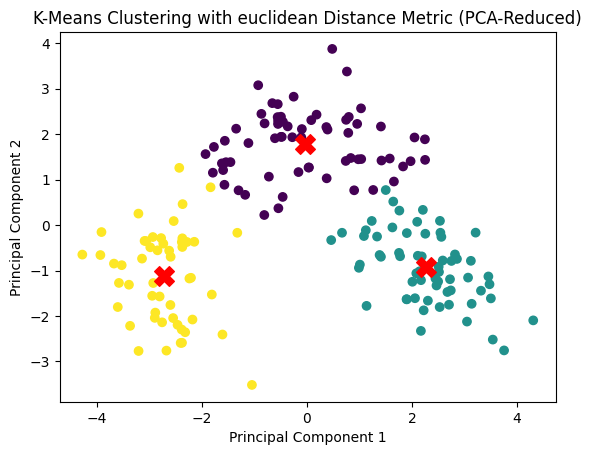

Silhouette Coefficient: 0.2848589191898987
Sum of Squared Errors (SSE): 1277.928488844642


In [10]:
## Euclidean Distance
n_clusters = 3
distance_metric = 'euclidean'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed

centroids, labels = kmeans_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_e, sse_e = evaluate_clustering(data_scaled, labels, centroids)


Iteration 1:
[[ 0.22660913 -0.50291274  0.06105693 -0.55019176  0.39420291  0.77423495
   0.82160365 -0.7046322   0.63362983 -0.13583653  0.56815911  0.76345076
   0.44687071]
 [ 0.4416159   0.05349102 -0.06380161 -0.2781221   0.04008669  0.74640632
   0.77410135 -0.42286506  0.49174628 -0.12745778  0.33338537  0.66014344
   0.6903799 ]
 [-0.31611089  0.32138091 -0.01793917  0.47541633 -0.28207754 -0.79959614
  -0.84190642  0.63339059 -0.61057518  0.13900005 -0.50792781 -0.76055385
  -0.55698309]]

Iteration 2:
[[ 0.29888197 -0.59829233 -0.02714436 -0.54217953  0.35538182  0.76165578
   0.83083117 -0.66322575  0.60979627 -0.08463908  0.68258595  0.69035848
   0.55907382]
 [ 0.23485199  0.27656654 -0.01028302 -0.20089603  0.0259465   0.67665668
   0.68752084 -0.34023524  0.55065605 -0.29348154  0.14281034  0.73627476
   0.35865444]
 [-0.3066731   0.37670585  0.02434317  0.48480049 -0.28418536 -0.80634132
  -0.86350494  0.62305002 -0.64840314  0.15894331 -0.5753712  -0.76991856
  -0.5480

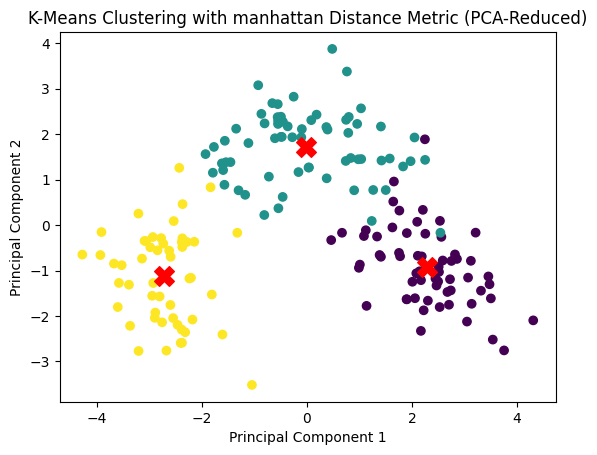

Silhouette Coefficient: 0.27688638122135556
Sum of Squared Errors (SSE): 1292.7095479918362


In [11]:

# Example usage:
n_clusters = 3
distance_metric = 'manhattan'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed

centroids, labels = kmeans_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_m, sse_m = evaluate_clustering(data_scaled, labels, centroids)


Iteration 1:
[[ 0.22237616 -0.45683192 -0.03553716 -0.52051561  0.24228761  0.74901268
   0.81008487 -0.71018267  0.6714051  -0.12395354  0.51460917  0.71597341
   0.48805738]
 [ 0.76951257  0.41684422  0.29732649 -0.06497338  0.55979079  0.67966635
   0.6568972  -0.10702784  0.02971231 -0.18486985  0.3684449   0.56461438
   0.7521079 ]
 [-0.3269595   0.34647757 -0.01617061  0.48267262 -0.31087796 -0.78998044
  -0.84166489  0.6615423  -0.6137857   0.14251807 -0.52671795 -0.7412852
  -0.56509287]]

Iteration 2:
[[ 0.14447385 -0.56252182 -0.33286378 -0.60223653  0.0341026   0.7128575
   0.75522944 -0.69741039  0.76084716 -0.18367139  0.54165931  0.7175373
   0.42513208]
 [ 0.6568917   0.26934534  0.88708963 -0.0765558   0.86913071  0.89103677
   0.94928099 -0.25667281  0.25493021  0.01812906  0.46045366  0.71231554
   0.80703587]
 [-0.29836283  0.3493426  -0.00239346  0.47886789 -0.27562114 -0.7968335
  -0.84571457  0.6028265  -0.6504502   0.13412742 -0.54322823 -0.74902702
  -0.55442085

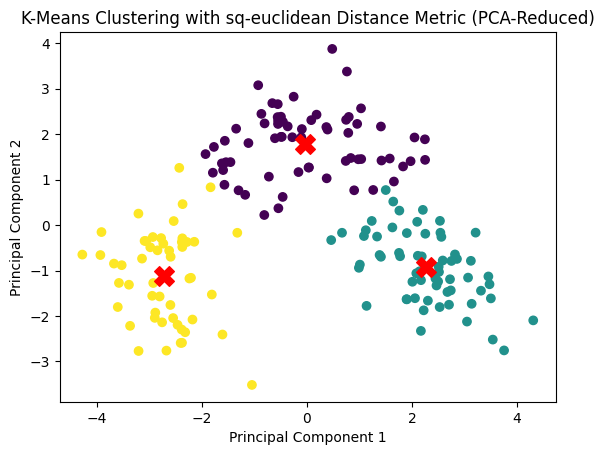

Silhouette Coefficient: 0.2848589191898987
Sum of Squared Errors (SSE): 1277.928488844642


In [12]:

# Example usage:
n_clusters = 3
distance_metric = 'sq-euclidean'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed

centroids, labels = kmeans_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_sqe, sse_sqe = evaluate_clustering(data_scaled, labels, centroids)


Iteration 1:
[[ 0.29136011 -0.45222541  0.04088809 -0.55319736  0.30469136  0.80271799
   0.86021015 -0.69005211  0.73643134 -0.085337    0.55782887  0.73018104
   0.57182744]
 [ 0.823776    0.58900319  0.22291419 -0.17615033  0.54474508  0.77428021
   0.73195566 -0.16937991  0.11231056 -0.11704906  0.26711827  0.60732396
   0.8864253 ]
 [-0.34180391  0.28692002 -0.06196401  0.46793922 -0.31613154 -0.74665754
  -0.78738064  0.57713495 -0.60699615  0.0839079  -0.48352995 -0.6665357
  -0.57556885]]

Iteration 2:
[[ 0.17178771 -0.54724199 -0.25170898 -0.64737881  0.08177586  0.71335823
   0.76766969 -0.70866537  0.76085545 -0.17862269  0.59594017  0.69699937
   0.48766698]
 [ 0.72546949  0.30586527  0.82452238 -0.02976139  0.907514    0.96455708
   0.97248936 -0.28353216  0.32037055  0.05958368  0.41701901  0.76798933
   0.85086512]
 [-0.31561868  0.30758579 -0.04087958  0.46829463 -0.30015546 -0.76449219
  -0.80522894  0.5795484  -0.62648491  0.1111316  -0.53498474 -0.70044115
  -0.57368

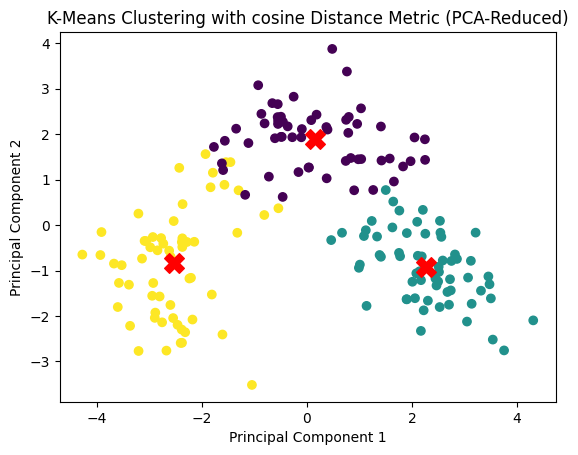

Silhouette Coefficient: 0.2781999909127299
Sum of Squared Errors (SSE): 1294.7985511454638


In [13]:
n_clusters = 3
distance_metric = 'cosine'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed

centroids, labels = kmeans_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_c, sse_c = evaluate_clustering(data_scaled, labels, centroids)


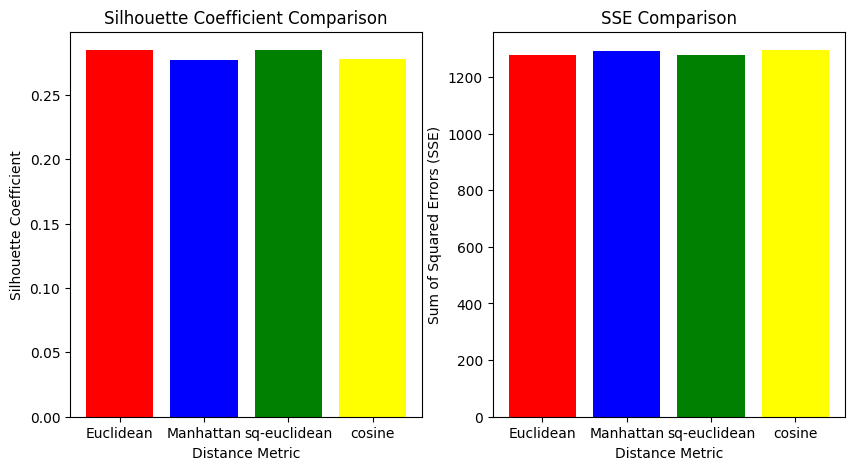

In [14]:
silhouette_avgs = [silhouette_avg_e, silhouette_avg_m, silhouette_avg_sqe, silhouette_avg_c]
sse_values = [sse_e, sse_m, sse_sqe, sse_c]
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].bar(['Euclidean', 'Manhattan', 'sq-euclidean', 'cosine'], silhouette_avgs,color = ['red','blue','green','yellow'])
axes[0].set_xlabel('Distance Metric')
axes[0].set_ylabel('Silhouette Coefficient')
axes[0].set_title('Silhouette Coefficient Comparison')
axes[1].bar(['Euclidean', 'Manhattan', 'sq-euclidean', 'cosine'], sse_values,color = ['red','blue','green','yellow'])
axes[1].set_xlabel('Distance Metric')
axes[1].set_ylabel('Sum of Squared Errors (SSE)')
axes[1].set_title('SSE Comparison')
plt.show()

## Kmeans++

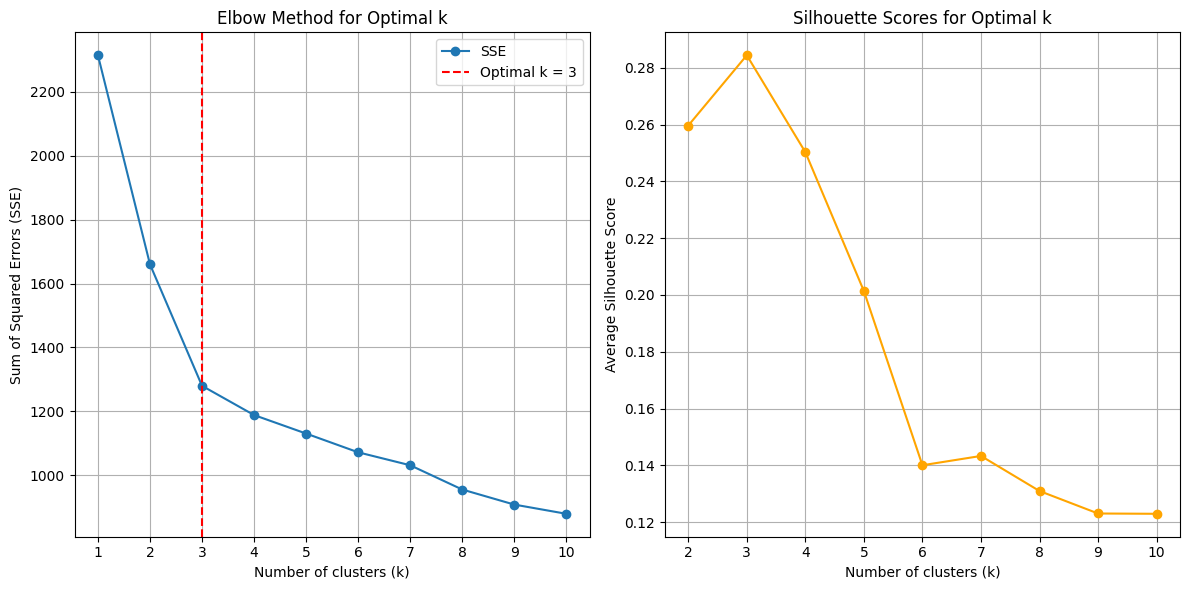

The optimal number of clusters is: 3


In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

def elbow_and_silhouette(df, max_k=10):
    """
    Use the Elbow Method and Silhouette Score to find the optimal number of clusters with KMeans++ initialization.

    Parameters:
    - df (pandas DataFrame): The dataset to cluster.
    - max_k (int): The maximum number of clusters to evaluate.

    Returns:
    - optimal_k (int): The optimal number of clusters based on the Elbow Method.
    """
    # Scale the data
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)

    sse = []
    silhouette_scores = []

    # Iterate over a range of k values (from 1 to max_k)
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
        kmeans.fit(df_scaled)
        sse.append(kmeans.inertia_)  # Inertia is the SSE for K-Means

        # Compute the silhouette score only if k > 1
        if k > 1:
            labels = kmeans.labels_
            silhouette_avg = silhouette_score(df_scaled, labels)
            silhouette_scores.append(silhouette_avg)
        else:
            silhouette_scores.append(None)  # No silhouette score for k = 1

    # Find the optimal k using the Elbow Method
    kneedle = KneeLocator(range(1, max_k + 1), sse, curve='convex', direction='decreasing')
    optimal_k = kneedle.elbow

    # Plot the SSE values with the dotted line for optimal k
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_k + 1), sse, marker='o', label='SSE')
    plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.legend()

    # Plot the Silhouette Scores
    plt.subplot(1, 2, 2)
    plt.plot(range(2, max_k + 1), silhouette_scores[1:], marker='o', color='orange')
    plt.title('Silhouette Scores for Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Average Silhouette Score')
    plt.xticks(range(2, max_k + 1))
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Print the optimal k value
    print(f"The optimal number of clusters is: {optimal_k}")

    return optimal_k

# Example usage with your DataFrame 'df'
optimal_k = elbow_and_silhouette(data, max_k=10)


In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def kmeans_plus_plus_init(df_scaled, n_clusters):
    """
    K-Means++ initialization for centroids.

    Parameters:
    - df_scaled (numpy array): Scaled dataset
    - n_clusters (int): Number of clusters

    Returns:
    - centroids (numpy array): Initial centroids
    """
    np.random.seed(42)
    n_samples = df_scaled.shape[0]

    # Randomly select the first centroid
    centroids = np.empty((n_clusters, df_scaled.shape[1]))
    centroids[0] = df_scaled[np.random.randint(n_samples)]

    for i in range(1, n_clusters):
        # Compute distances from each point to the nearest centroid
        distances = pairwise_distances(df_scaled, centroids[:i], metric='euclidean').min(axis=1)
        # Select the next centroid with probability proportional to the square of the distance
        probabilities = distances ** 2
        probabilities /= probabilities.sum()
        centroids[i] = df_scaled[np.random.choice(n_samples, p=probabilities)]

    return centroids

def kpp_clustering(df_scaled, n_clusters, distance_metric):
    """
    Perform K-Means clustering on the customer clustering dataset
    with the specified distance metric and K-Means++ initialization.

    Parameters:
    - df_scaled (numpy array): Scaled dataset
    - n_clusters (int): Number of clusters
    - distance_metric (str): Distance metric to use (euclidean, manhattan, sq-euclidean, cosine)

    Returns:
    - centroids (numpy array): Final centroids
    - labels (numpy array): Cluster labels for each data point
    """
    # Initialize centroids using K-Means++
    centroids = kmeans_plus_plus_init(df_scaled, n_clusters)

    for iteration in range(100):  # Maximum iterations
        # Calculate distances based on the selected metric
        if distance_metric == 'euclidean':
            distances = pairwise_distances(df_scaled, centroids, metric='euclidean')
        elif distance_metric == 'manhattan':
            distances = pairwise_distances(df_scaled, centroids, metric='manhattan')
        elif distance_metric == 'sq-euclidean':
            distances = pairwise_distances(df_scaled, centroids, metric='sqeuclidean')
        elif distance_metric == 'cosine':
            distances = pairwise_distances(df_scaled, centroids, metric='cosine')
        else:
            raise ValueError("Invalid distance metric. Supported metrics are: euclidean, manhattan, sq-euclidean, cosine")

        # Assign clusters based on the nearest centroid
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([df_scaled[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i] for i in range(n_clusters)])

        # Print centroids after each iteration
        print(f"Iteration {iteration + 1}:")
        print(new_centroids)
        print()

        # Check for convergence
        if np.allclose(centroids, new_centroids, atol=1e-4):
            print("Centroids have stabilized. Stopping iteration.")
            break

        centroids = new_centroids

    # Apply PCA for dimensionality reduction to 2D for plotting
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df_scaled)
    centroids_pca = pca.transform(centroids)

    # Plot final clusters in 2D space
    plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis')
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200)
    plt.title(f"K-Means++ Clustering with {distance_metric} Distance Metric (PCA-Reduced)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

    return centroids, labels

def evaluate_clustering(df_scaled, labels, centroids):
    """
    Evaluate the K-Means clustering results using Silhouette Coefficient and Sum of Squared Errors (SSE).

    Parameters:
    - df_scaled (numpy array): Scaled dataset used for clustering
    - labels (numpy array): Cluster labels for each data point
    - centroids (numpy array): Final centroids

    Returns:
    - silhouette_avg (float): Average Silhouette Coefficient
    - sse (float): Sum of Squared Errors (SSE)
    """
    # 1. Silhouette Coefficient
    silhouette_avg = silhouette_score(df_scaled, labels)
    print(f"Silhouette Coefficient: {silhouette_avg}")

    # 2. Sum of Squared Errors (SSE)
    sse = np.sum((df_scaled - centroids[labels])**2)
    print(f"Sum of Squared Errors (SSE): {sse}")

    return silhouette_avg, sse


Iteration 1:
[[-0.68245726 -0.10955619 -0.16238425  0.23755627 -0.47253193 -0.12370862
  -0.08133521  0.17807393 -0.1806542  -0.71628423  0.25943192  0.1561087
  -0.58023773]
 [ 0.24238879  0.86125497  0.20415652  0.58233269  0.06988117 -1.00711892
  -1.19557238  0.50669829 -0.63831917  1.29045397 -1.35927589 -1.40776112
  -0.35380931]
 [ 0.91630649 -0.43158994  0.11494625 -0.78812002  0.70337522  0.90573074
   0.97086256 -0.64016469  0.73689611  0.23265173  0.54335812  0.74202915
   1.17305922]]

Iteration 2:
[[-0.90082234 -0.27839783 -0.38880157  0.22718702 -0.5488809  -0.09000771
   0.03511149  0.04854712 -0.06528706 -0.87067117  0.38052433  0.25506928
  -0.76051284]
 [ 0.18654314  0.90497145  0.24921026  0.58370348 -0.05063539 -0.988557
  -1.23619475  0.71684172 -0.74960756  0.98849829 -1.19129878 -1.30153966
  -0.38004461]
 [ 0.79862953 -0.41221182  0.21348573 -0.69199704  0.61440117  0.86317146
   0.92470134 -0.60840244  0.65142407  0.14329971  0.52792118  0.74509318
   1.0923179

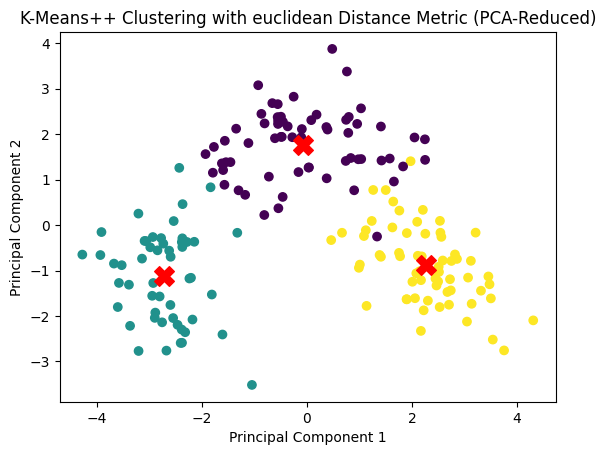

Silhouette Coefficient: 0.2844212860533542
Sum of Squared Errors (SSE): 1279.9661527749454


In [17]:
## Euclidean Distance
n_clusters = 3
distance_metric = 'euclidean'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed
centroids, labels = kpp_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_e, sse_e = evaluate_clustering(data_scaled, labels, centroids)

Iteration 1:
[[-0.71126947 -0.10998272 -0.19124496  0.22802957 -0.49675281 -0.15991865
  -0.0921027   0.16213415 -0.18370513 -0.75259316  0.26013103  0.17077451
  -0.5895384 ]
 [ 0.24073093  0.86727876  0.1973268   0.57205978  0.05676236 -1.00964891
  -1.21055262  0.57328121 -0.66517677  1.23851711 -1.31707662 -1.38304337
  -0.36348849]
 [ 0.84181737 -0.45232543  0.13329421 -0.72548748  0.66607866  0.93577836
   0.98039339 -0.63270376  0.72784538  0.20033968  0.55460441  0.72787719
   1.09284474]]

Iteration 2:
[[-0.96141943 -0.38906986 -0.50295216  0.15119881 -0.38585174 -0.11074091
  -0.01563915  0.01357361  0.05152672 -0.90411014  0.43885446  0.22469682
  -0.73057488]
 [ 0.17711479  0.90650664  0.21596904  0.55103983 -0.07734512 -0.99010047
  -1.22711807  0.71348704 -0.76127859  0.95438352 -1.19006316 -1.28939841
  -0.39632062]
 [ 0.85137339 -0.31802843  0.3475149  -0.59333198  0.45948602  0.90005052
   0.99003886 -0.58026407  0.55102687  0.17536481  0.49170823  0.79150202
   1.0683

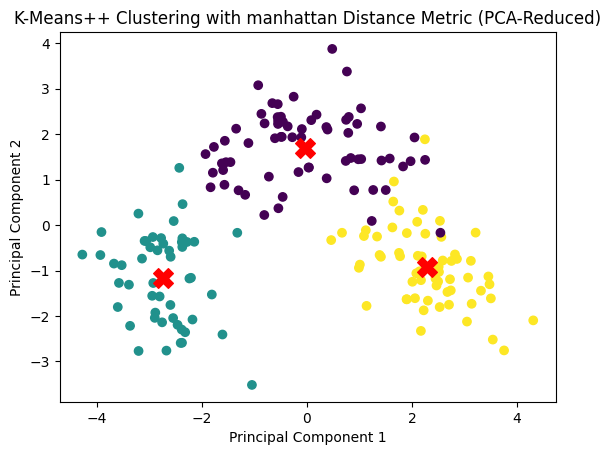

Silhouette Coefficient: 0.27674870485774766
Sum of Squared Errors (SSE): 1292.9363924654517


In [18]:
## manhattan Distance
n_clusters = 3
distance_metric = 'manhattan'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed
centroids, labels = kpp_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_m, sse_m = evaluate_clustering(data_scaled, labels, centroids)

Iteration 1:
[[-0.68245726 -0.10955619 -0.16238425  0.23755627 -0.47253193 -0.12370862
  -0.08133521  0.17807393 -0.1806542  -0.71628423  0.25943192  0.1561087
  -0.58023773]
 [ 0.24238879  0.86125497  0.20415652  0.58233269  0.06988117 -1.00711892
  -1.19557238  0.50669829 -0.63831917  1.29045397 -1.35927589 -1.40776112
  -0.35380931]
 [ 0.91630649 -0.43158994  0.11494625 -0.78812002  0.70337522  0.90573074
   0.97086256 -0.64016469  0.73689611  0.23265173  0.54335812  0.74202915
   1.17305922]]

Iteration 2:
[[-0.90082234 -0.27839783 -0.38880157  0.22718702 -0.5488809  -0.09000771
   0.03511149  0.04854712 -0.06528706 -0.87067117  0.38052433  0.25506928
  -0.76051284]
 [ 0.18654314  0.90497145  0.24921026  0.58370348 -0.05063539 -0.988557
  -1.23619475  0.71684172 -0.74960756  0.98849829 -1.19129878 -1.30153966
  -0.38004461]
 [ 0.79862953 -0.41221182  0.21348573 -0.69199704  0.61440117  0.86317146
   0.92470134 -0.60840244  0.65142407  0.14329971  0.52792118  0.74509318
   1.0923179

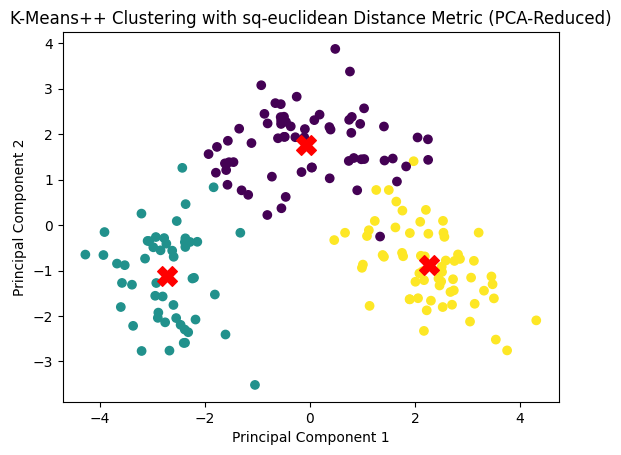

Silhouette Coefficient: 0.2844212860533542
Sum of Squared Errors (SSE): 1279.9661527749454


In [19]:
## sq-euclidean Distance
n_clusters = 3
distance_metric = 'sq-euclidean'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed
centroids, labels = kpp_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_sqe, sse_sqe = evaluate_clustering(data_scaled, labels, centroids)

Iteration 1:
[[-1.00948540e+00 -3.00741893e-01 -2.32106786e-01  3.59593984e-01
  -6.01852025e-01 -1.33959605e-01 -1.16104271e-03  2.13112486e-01
  -1.39096982e-01 -9.52296808e-01  3.26581886e-01  3.30209787e-01
  -8.29430998e-01]
 [ 1.22050478e-01  8.19633563e-01  2.25725989e-01  5.51270819e-01
   3.29219856e-03 -9.98247707e-01 -1.21638335e+00  6.68425308e-01
  -7.44525966e-01  8.99240831e-01 -1.12563678e+00 -1.28525887e+00
  -3.76226467e-01]
 [ 6.45973990e-01 -3.65501712e-01  7.72477000e-03 -6.53761147e-01
   4.34615931e-01  8.08338902e-01  8.67307798e-01 -6.30864079e-01
   6.31335484e-01  5.08384605e-02  5.64716063e-01  6.75785515e-01
   8.70186564e-01]]

Iteration 2:
[[-1.01866504e+00 -2.88698766e-01 -3.73964505e-01  2.83891551e-01
  -5.89138785e-01 -1.47622651e-01  3.84260198e-02  9.24987850e-02
  -3.79911796e-05 -9.28667977e-01  4.18366000e-01  3.17277589e-01
  -8.33159417e-01]
 [ 1.50032187e-01  8.02706294e-01  1.68601340e-01  4.95572094e-01
  -5.47178800e-02 -9.71404584e-01 -1.2

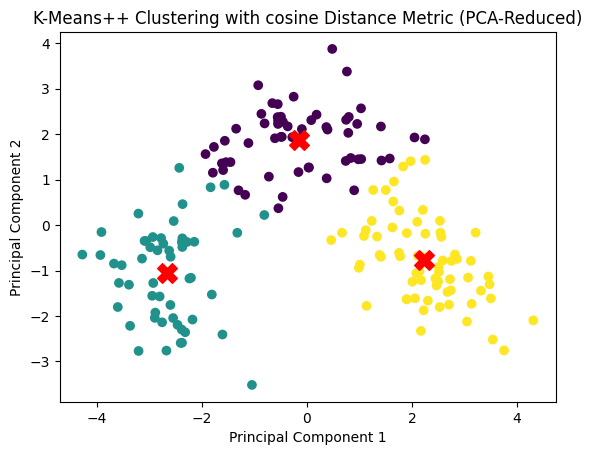

Silhouette Coefficient: 0.2802762199395535
Sum of Squared Errors (SSE): 1284.6740739385716


In [20]:
## cosine Distance
n_clusters = 3
distance_metric = 'cosine'  # Change this to 'manhattan', 'sq-euclidean', or 'cosine' as needed
centroids, labels = kpp_clustering(data_scaled, n_clusters, distance_metric)
silhouette_avg_c, sse_c = evaluate_clustering(data_scaled, labels, centroids)

## Summary

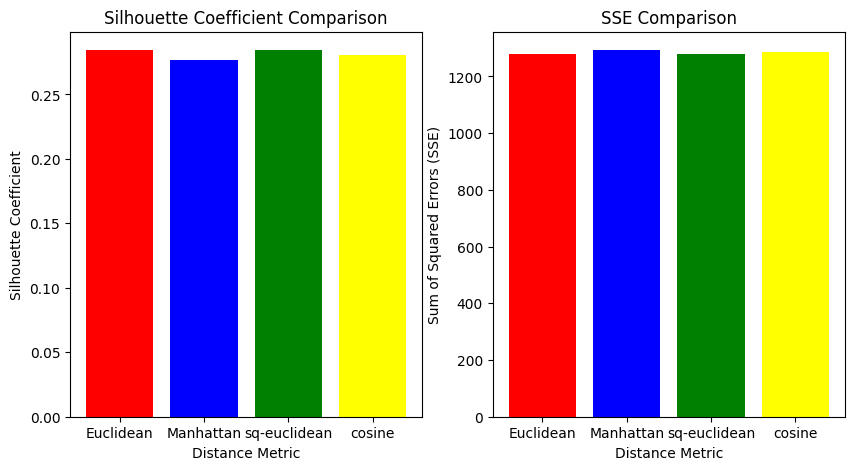

In [21]:
silhouette_avgs = [silhouette_avg_e, silhouette_avg_m, silhouette_avg_sqe, silhouette_avg_c]
sse_values = [sse_e, sse_m, sse_sqe, sse_c]
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].bar(['Euclidean', 'Manhattan', 'sq-euclidean', 'cosine'], silhouette_avgs,color = ['red','blue','green','yellow'])
axes[0].set_xlabel('Distance Metric')
axes[0].set_ylabel('Silhouette Coefficient')
axes[0].set_title('Silhouette Coefficient Comparison')
axes[1].bar(['Euclidean', 'Manhattan', 'sq-euclidean', 'cosine'], sse_values,color = ['red','blue','green','yellow'])
axes[1].set_xlabel('Distance Metric')
axes[1].set_ylabel('Sum of Squared Errors (SSE)')
axes[1].set_title('SSE Comparison')
plt.show()